In [27]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [28]:
import sys
import warnings
from pathlib import Path
warnings.filterwarnings("ignore")

_HERE = Path.cwd()
_ROOT = _HERE.parent if _HERE.name == "GeneralRnaseqComparison" else _HERE
for _p in (str(_ROOT),):
    if _p not in sys.path:
        sys.path.insert(0, _p)

import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc

from viz_style import apply_style
apply_style()

from config import PATHS

OUT_DIR = _ROOT / "GeneralRnaseqComparison"
RAW_DIR = OUT_DIR / "raw"
GTEX_MD_PATH = RAW_DIR / "gtex.gtex.BLOOD.MD.gz"
GTEX_COUNTS_PATH = RAW_DIR / "gtex.gene_sums.BLOOD.G026.gz"
CFRNA_STATS_CACHE = OUT_DIR / "cfrna_gene_stats.csv"
GTEX_STATS_CACHE = OUT_DIR / "gtex_gene_stats.csv"
SUMMARY_CACHE = OUT_DIR / "summary_stats.csv"
LIBSIZE_CACHE = OUT_DIR / "libsize_stats.csv"


## 1. cfRNA HC gene-level stats

In [29]:
if CFRNA_STATS_CACHE.is_file():
    cfrna_stats = pd.read_csv(CFRNA_STATS_CACHE, index_col=0)
else:
    adata = sc.read_h5ad(PATHS["merged_qc"])
    hc = adata[(adata.obs["Phenotype_Processed"] == "Healthy Control") & (adata.obs["QC_Passed"] == True)]
    raw = hc.layers["Raw"]
    raw = raw.toarray() if hasattr(raw, "toarray") else np.asarray(raw)
    cpm = raw / raw.sum(axis=1, keepdims=True) * 1e6

    gene_ids = hc.var_names.str.replace(r"\.\d+$", "", regex=True)
    cfrna_stats = pd.DataFrame({
        "mean": cpm.mean(axis=0),
        "var": cpm.var(axis=0),
        "zero_frac": (raw == 0).mean(axis=0),
    }, index=gene_ids)
    cfrna_stats["dispersion"] = cfrna_stats["var"] / cfrna_stats["mean"].replace(0, np.nan)
    cfrna_stats.to_csv(CFRNA_STATS_CACHE)

print(cfrna_stats.shape)
cfrna_stats.head()

(78691, 4)


,mean,var,zero_frac,dispersion
ENSG00000000003,1.637631,9.791450,0.440763,5.979033
ENSG00000000005,0.324256,2.650334,0.846386,8.173581
ENSG00000000419,22.413317,465.358700,0.021084,20.762598
ENSG00000000457,11.748729,145.967800,0.051205,12.424136
ENSG00000000460,9.096687,82.687780,0.131526,9.089878


## 2. GTEx Whole Blood HC gene-level stats

In [30]:
if GTEX_STATS_CACHE.is_file():
    gtex_stats = pd.read_csv(GTEX_STATS_CACHE, index_col=0)
else:
    md = pd.read_csv(GTEX_MD_PATH, sep="\t")
    wb_samples = md.loc[md["SMTSD"] == "Whole Blood", "external_id"]

    counts = pd.read_csv(GTEX_COUNTS_PATH, sep="\t", skiprows=2, index_col=0)
    counts = counts[[c for c in wb_samples if c in counts.columns]]

    cpm = counts.div(counts.sum(axis=0), axis=1) * 1e6
    gene_ids = counts.index.str.replace(r"\.\d+$", "", regex=True)

    gtex_stats = pd.DataFrame({
        "mean": cpm.mean(axis=1).values,
        "var": cpm.var(axis=1).values,
        "zero_frac": (counts == 0).mean(axis=1).values,
    }, index=gene_ids)
    gtex_stats["dispersion"] = gtex_stats["var"] / gtex_stats["mean"].replace(0, np.nan)
    gtex_stats.to_csv(GTEX_STATS_CACHE)

print(gtex_stats.shape)
gtex_stats.head()

(63856, 4)


,mean,var,zero_frac,dispersion
gene_id,,,,
ENSG00000278704,0.0,0.0,1.0,NaN
ENSG00000277400,0.0,0.0,1.0,NaN
ENSG00000274847,0.0,0.0,1.0,NaN
ENSG00000277428,0.0,0.0,1.0,NaN
ENSG00000276256,0.0,0.0,1.0,NaN


## 3. Common gene set + summary comparison

In [31]:
common_genes = cfrna_stats.index.intersection(gtex_stats.index)
cf = cfrna_stats.loc[common_genes]
gt = gtex_stats.loc[common_genes]
print(f"common genes: {len(common_genes)}")

if SUMMARY_CACHE.is_file():
    summary = pd.read_csv(SUMMARY_CACHE, index_col=0)
else:
    summary = pd.DataFrame({
        "cfRNA_HC": [
            cf["zero_frac"].mean(),
            (cf["zero_frac"] > 0.9).mean(),
            cf["dispersion"].median(),
        ],
        "GTEx_WholeBlood": [
            gt["zero_frac"].mean(),
            (gt["zero_frac"] > 0.9).mean(),
            gt["dispersion"].median(),
        ],
    }, index=["mean_zero_frac", "frac_genes_zerofrac>0.9", "median_dispersion"])
    summary.to_csv(SUMMARY_CACHE)

summary

common genes: 56503


,cfRNA_HC,GTEx_WholeBlood
mean_zero_frac,0.782540,0.475574
frac_genes_zerofrac>0.9,0.702529,0.323894
median_dispersion,13.283701,0.130374


## 4. Figures

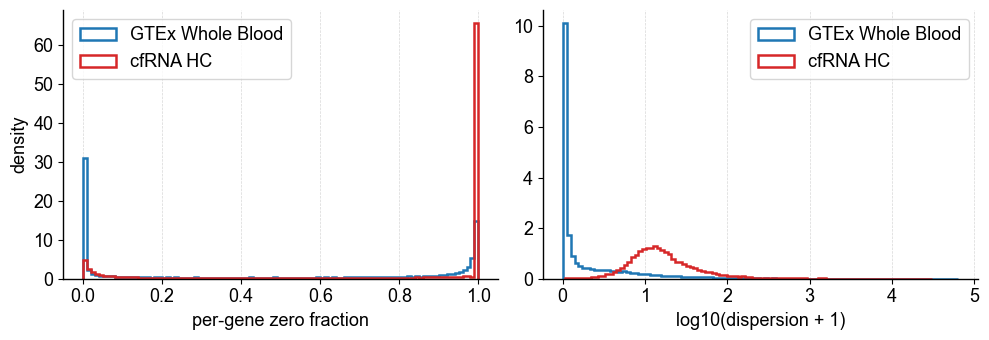

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

for df, label, color in [(gt, "GTEx Whole Blood", "tab:blue"),(cf, "cfRNA HC", "tab:red")]:
    axes[0].hist(df["zero_frac"], bins=100, density=True, label=label, histtype="step", lw=1.8, color=color)
axes[0].set_xlabel("per-gene zero fraction")
axes[0].set_ylabel("density")
axes[0].grid(axis="x", ls="--", lw=0.5, alpha=0.5)
axes[0].legend()

for df, label, color in [(gt, "GTEx Whole Blood", "tab:blue"),(cf, "cfRNA HC", "tab:red")]:
    vals = np.log10(df["dispersion"].dropna() + 1)
    axes[1].hist(vals, bins=100, density=True, label=label, histtype="step", lw=1.8, color=color)
axes[1].set_xlabel("log10(dispersion + 1)")
axes[1].legend()
axes[1].grid(axis="x", ls="--", lw=0.5, alpha=0.5)
fig.tight_layout()


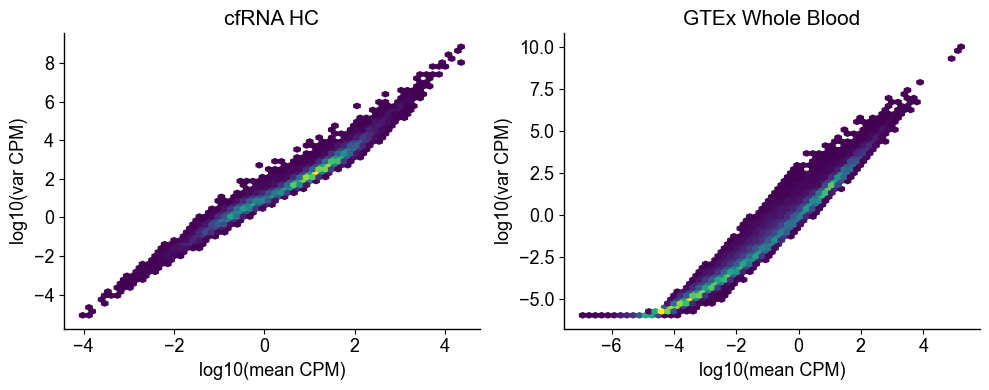

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, df, title, cmap in zip(axes, [cf, gt], ["cfRNA HC", "GTEx Whole Blood"], ["viridis", "viridis"]):
    m = df["mean"] > 0
    ax.hexbin(np.log10(df.loc[m, "mean"]), np.log10(df.loc[m, "var"] + 1e-6), gridsize=60, mincnt=1, cmap=cmap)
    ax.set_xlabel("log10(mean CPM)")
    ax.set_ylabel("log10(var CPM)")
    ax.set_title(title)
fig.tight_layout()


## 5. Noise overlay: CV^2 vs mean (technical-noise diagnostic)

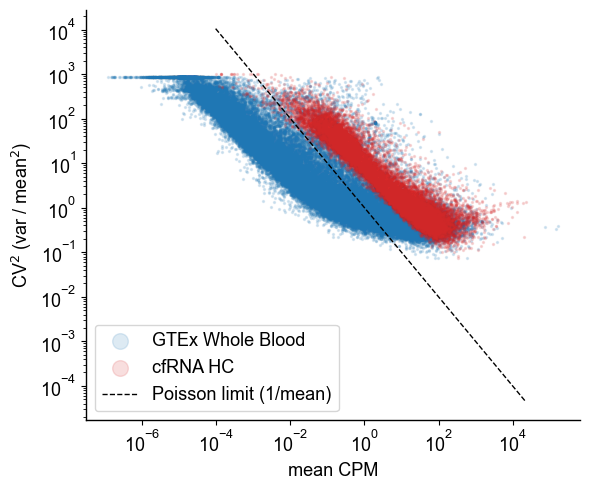

In [34]:
fig, ax = plt.subplots(figsize=(6, 5))
for df, label, color in [(gt, "GTEx Whole Blood", "tab:blue"), (cf, "cfRNA HC", "tab:red")]:
    m = df["mean"] > 0
    cv2 = df.loc[m, "var"] / df.loc[m, "mean"] ** 2
    ax.scatter(df.loc[m, "mean"], cv2, s=2, alpha=0.15, color=color, label=label, rasterized=True)

x = np.logspace(np.log10(cf["mean"][cf["mean"] > 0].min()), np.log10(cf["mean"].max()), 200)
ax.plot(x, 1 / x, "k--", lw=1, label="Poisson limit (1/mean)")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("mean CPM")
ax.set_ylabel("CV$^2$ (var / mean$^2$)")
ax.legend(markerscale=8)
fig.tight_layout()

## 6. Total library size distribution (raw read counts)

In [35]:
if LIBSIZE_CACHE.is_file():
    libsize = pd.read_csv(LIBSIZE_CACHE)
else:
    adata = sc.read_h5ad(PATHS["merged_qc"])
    hc = adata[(adata.obs["Phenotype_Processed"] == "Healthy Control") & (adata.obs["QC_Passed"] == True)]
    raw = hc.layers["Raw"]
    raw = raw.toarray() if hasattr(raw, "toarray") else np.asarray(raw)
    cf_libsize = raw.sum(axis=1)

    md_gtex = pd.read_csv(GTEX_MD_PATH, sep="\t")
    wb_samples = md_gtex.loc[md_gtex["SMTSD"] == "Whole Blood", "external_id"]
    counts = pd.read_csv(GTEX_COUNTS_PATH, sep="\t", skiprows=2, index_col=0)
    counts = counts[[c for c in wb_samples if c in counts.columns]]
    gt_libsize = counts.sum(axis=0).values

    libsize = pd.concat([
        pd.DataFrame({"total_count": cf_libsize, "source": "cfRNA HC"}),
        pd.DataFrame({"total_count": gt_libsize, "source": "GTEx Whole Blood"}),
    ], ignore_index=True)
    libsize.to_csv(LIBSIZE_CACHE, index=False)

libsize.groupby("source")["total_count"].describe()


,count,mean,std,min,25%,50%,75%,max
source,,,,,,,,
GTEx Whole Blood,852.0,6.367112e+09,2.284463e+09,4.321720e+08,5.023926e+09,6.218256e+09,7.396296e+09,2.555485e+10
cfRNA HC,996.0,6.668793e+06,6.301649e+06,3.388093e+05,2.450346e+06,4.589806e+06,8.196127e+06,3.386702e+07


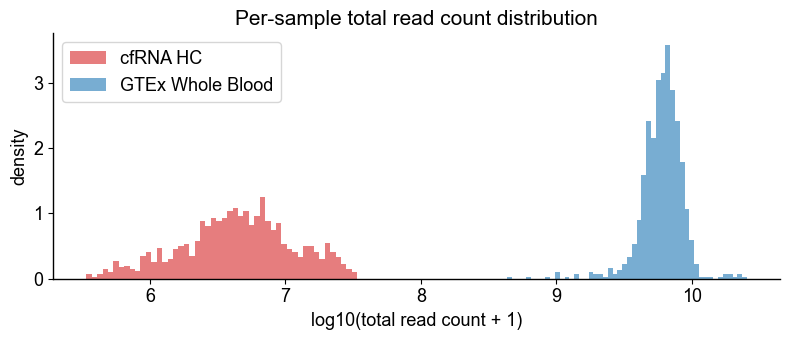

In [40]:
fig, ax = plt.subplots(figsize=(8, 3.5))
for src_name, color in [("cfRNA HC", "tab:red"), ("GTEx Whole Blood", "tab:blue")]:
    vals = libsize.loc[libsize["source"] == src_name, "total_count"]
    ax.hist(np.log10(vals + 1), bins=50, alpha=0.6, density=True, label=src_name, color=color)
ax.set_xlabel("log10(total read count + 1)")
ax.set_ylabel("density")
ax.set_title("Per-sample total read count distribution")
ax.legend()
fig.tight_layout()
